# Regresión Lineal con Redes Neuronales
**Dataset:** California Housing

En este notebook voy a usar una red neuronal para hacer regresión lineal. La idea que tengo es predecir el precio de casas en California usando datos como el ingreso de la zona, cuántos cuartos tienen las casas, etc.

Aparte voy a mostrar qué pasa cuando el modelo aprende muy poco (underfitting) y que pasa cuando aprende demasiado (overfitting).

---
## 1 - Preparacion de los datos

In [8]:
# Importamos todas las librerias y dependencias necesarias 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Esto es para que los resultados sean iguales cada vez que corro el notebook
np.random.seed(42)
tf.random.set_seed(42)



In [9]:
# Importo el dataset de california housing que viene incluido en sklearn
datos = fetch_california_housing()

X = datos.data    # las variables de entrada (ingreso, habitaciones, etc)
y = datos.target  # lo que quiero predecir (precio de la casa)

print("forma de X:", X.shape)
print("forma de y:", y.shape)
print("\nColumnas:", datos.feature_names)
print("\nprimeros 5 valores del precio:", y[:5])

forma de X: (20640, 8)
forma de y: (20640,)

Columnas: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

primeros 5 valores del precio: [4.526 3.585 3.521 3.413 3.422]


---
El dataset tiene 20,640 casas con 8 características cada una. El precio está en cientos de miles de dólares.

Las 8 características son:
- MedInc: ingreso mediano de la zona
- HouseAge: edad de las casas
- AveRooms: promedio de habitaciones
- AveBedrms: promedio de dormitorios
- Population: población del bloque
- AveOccup: promedio de ocupantes
- Latitude y Longitude: ubicación geográfica

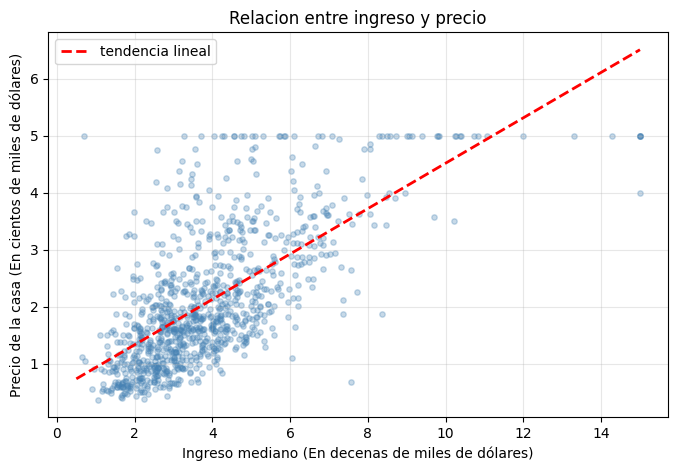

la linea roja muestra la tendencia lineal positiva entre ingreso y precio


In [15]:
muestra = np.random.choice(len(X), 1000, replace=False)

plt.figure(figsize=(8, 5))
plt.scatter(X[muestra, 0], y[muestra], alpha=0.3, color='steelblue', s=15)

# Linea de tendencia
m, b = np.polyfit(X[muestra, 0], y[muestra], 1)
x_linea = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
plt.plot(x_linea, m * x_linea + b, color='red', linewidth=2, 
         linestyle='--', label='tendencia lineal')

plt.xlabel('Ingreso mediano (En decenas de miles de dólares)')
plt.ylabel('Precio de la casa (En cientos de miles de dólares)')
plt.title('Relacion entre ingreso y precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("la linea roja muestra la tendencia lineal positiva entre ingreso y precio")

In [16]:
# Division en entrenamiento y prueba (80% para entrenar, 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizo los datos para que la red neuronal aprenda mejor
# esto hace que todos los valores tengan media 0 y desviacion 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("datos de entrenamiento:", X_train.shape)
print("datos de prueba:", X_test.shape)

datos de entrenamiento: (16512, 8)
datos de prueba: (4128, 8)
